In [150]:
library(auk)
library(tidyverse)

library(magrittr)
library(httr)
library(data.table)
library(plotly)
# library(elevatr)
library(readr)
library(raster)

library(sf)
library(terra)
# library(prism)
# library(rnaturalearth)
library(dggridR)
library(lubridate)
library(hms)

library(gridExtra)

select <- dplyr::select
projection <- raster::projection

readRenviron("~/.Renviron")
R.home()

[1] "/usr/lib/R"

In [34]:
PROJECT_DIR = getwd()

ebd_dir = file.path(PROJECT_DIR, "source_data", "ebd_relMar-2026")
ebd_filename = "ebd_relMar-2026.txt"

sed_dir = file.path(PROJECT_DIR, "source_data", "ebd_sampling_relMar-2026")
sed_filename = "ebd_sampling_relMar-2026.txt"

In [36]:
auk_version()
auk_ebd_version(file.path(ebd_dir, ebd_filename))

$auk_version
[1] "auk 0.9.0"

$ebd_version
[1] "2025-10-28"

$taxonomy_version
[1] 2025

In [ ]:
# source("ebd_functions.R")
# source("land_cover_functions.R")
# source("climate_functions.R")
# dist_to_coast_df = read_in_dist_to_coast_data(file.path(PROJECT_DIR, "source_data", "NASA_dist2coast.txt"))

<span style="color:deepskyblue">Citation:  
*eBird Basic Dataset. Version: EBD_relSep-2025. Cornell Lab of Ornithology, Ithaca, New York. Sep 2025.*</span>

### Data extraction

In [ ]:
# print all columns
readLines(file.path(ebd_dir, ebd_filename), n = 1) |> strsplit("\t") |> unlist()

[1] "GLOBAL UNIQUE IDENTIFIER"   "LAST EDITED DATE"          
 [3] "TAXONOMIC ORDER"            "CATEGORY"                  
 [5] "TAXON CONCEPT ID"           "COMMON NAME"               
 [7] "SCIENTIFIC NAME"            "SUBSPECIES COMMON NAME"    
 [9] "SUBSPECIES SCIENTIFIC NAME" "EXOTIC CODE"               
[11] "OBSERVATION COUNT"          "BREEDING CODE"             
[13] "BREEDING CATEGORY"          "BEHAVIOR CODE"             
[15] "AGE/SEX"                    "COUNTRY"                   
[17] "COUNTRY CODE"               "STATE"                     
[19] "STATE CODE"                 "COUNTY"                    
[21] "COUNTY CODE"                "IBA CODE"                  
[23] "BCR CODE"                   "USFWS CODE"                
[25] "ATLAS BLOCK"                "LOCALITY"                  
[27] "LOCALITY ID"                "LOCALITY TYPE"             
[29] "LATITUDE"                   "LONGITUDE"                 
[31] "OBSERVATION DATE"           "TIME OBSERVATIONS STARTED" 
[33] "OBSERVER ID"                "OBSERVER ORCID ID"         
[35] "SAMPLING EVENT IDENTIFIER"  "OBSERVATION TYPE"          
[37] "PROTOCOL NAME"              "PROTOCOL CODE"             
[39] "PROJECT NAMES"              "PROJECT IDENTIFIERS"       
[41] "DURATION MINUTES"           "EFFORT DISTANCE KM"        
[43] "EFFORT AREA HA"             "NUMBER OBSERVERS"          
[45] "ALL SPECIES REPORTED"       "GROUP IDENTIFIER"          
[47] "HAS MEDIA"                  "APPROVED"                  
[49] "REVIEWED"                   "REASON"                    
[51] "CHECKLIST COMMENTS"         "SPECIES COMMENTS"

#### <span style="color:orange">Swallow-tailed Kite, Fall migration</span>

In [ ]:
file.desc <- "swallow_tailed_kite_20260725"
f_out_ebd_only <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, ".txt"))
f_out_sed_only <- file.path(PROJECT_DIR, "output", "auk", paste0("sed_", file.desc, ".txt"))

species_name = "Swallow-tailed Kite"
# Full dataset filtering
f_in_ebd <- file.path(ebd_dir, ebd_filename)
f_in_sed <- file.path(sed_dir, sed_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species(species_name) %>%
    auk_bbox(bbox = c(longitude_min = -108, latitude_min = -15, longitude_max = -50, latitude_max = 40)) %>%
    auk_date(c("*-08-01", "*-10-31")) %>%
    auk_complete()
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only, file_sampling = f_out_sed_only,
           keep = c("SCIENTIFIC NAME", "OBSERVATION COUNT",
                    "LATITUDE", "LONGITUDE", "COUNTRY", "COUNTRY CODE", "STATE", "STATE CODE",
                    "OBSERVATION DATE", "TIME OBSERVATIONS STARTED", "DURATION MINUTES",
                    "EFFORT DISTANCE KM", "NUMBER OBSERVERS", "PROTOCOL NAME", "ALL SPECIES REPORTED",
                    "SAMPLING EVENT IDENTIFIER", "OBSERVER ID", "GROUP IDENTIFIER"),
           overwrite = TRUE)

Warning message in auk_species.auk_ebd(., "Swallow-tailed Kite"):
“Based on the EBD filename, it appears you should use taxonomy_version = 2025”
Warning message in auk_filter.auk_ebd(ebd_filters, file = f_out_ebd_only, file_sampling = f_out_sed_only, :
“Sampling event data file provided, but filters have not been  set to only return complete checklists. Complete checklists  are required for zero-filling. You may want to use  auk_complete(), or manually filter out incomplete checklists.”


In [ ]:
# file.desc <- "swallow_tailed_kite_20260725"
# f_out_ebd_only <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, ".txt"))
# f_out_sed_only <- file.path(PROJECT_DIR, "output", "auk", paste0("sed_", file.desc, ".txt"))

# ebd_filters2 <- auk_ebd(f_out_ebd_only, file_sampling = f_out_sed_only) %>%
#     auk_complete()

# f_out_ebd_complete <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, "_complete.txt"))
# f_out_sed_complete <- file.path(PROJECT_DIR, "output", "auk", paste0("sed_", file.desc, "_complete.txt"))

# auk_filter(ebd_filters2, file = f_out_ebd_complete, file_sampling = f_out_sed_complete,
#            overwrite = TRUE)

ERROR: Error in auk_ebd(f_out_ebd_only, file_sampling = f_out_sed_only): Required columns missing from the EBD file:
	exotic code


#### <span style="color:orange">Broad-winged Hawk, Fall migration</span>

In [ ]:
file.desc <- "broad_winged_hawk_20260725"
f_out_ebd_only <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, ".txt"))
f_out_sed_only <- file.path(PROJECT_DIR, "output", "auk", paste0("sed_", file.desc, ".txt"))

species_name = "Broad-winged Hawk"
# Full dataset filtering
f_in_ebd <- file.path(ebd_dir, ebd_filename)
f_in_sed <- file.path(sed_dir, sed_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species(species_name) %>%
    auk_bbox(bbox = c(longitude_min = -108, latitude_min = -15, longitude_max = -50, latitude_max = 40)) %>%
    auk_date(c("*-08-01", "*-10-31")) %>%
    auk_complete()
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only, file_sampling = f_out_sed_only,
           keep = c("SCIENTIFIC NAME", "OBSERVATION COUNT",
                    "LATITUDE", "LONGITUDE", "COUNTRY", "COUNTRY CODE", "STATE", "STATE CODE",
                    "OBSERVATION DATE", "TIME OBSERVATIONS STARTED", "DURATION MINUTES",
                    "EFFORT DISTANCE KM", "NUMBER OBSERVERS", "PROTOCOL NAME", "ALL SPECIES REPORTED",
                    "SAMPLING EVENT IDENTIFIER", "OBSERVER ID", "GROUP IDENTIFIER"),
           overwrite = TRUE)

#### <span style="color:orange">Mississippi Kite, Fall migration</span>

In [ ]:
file.desc <- "mississippi_kite_20260726"
f_out_ebd_only <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, ".txt"))
f_out_sed_only <- file.path(PROJECT_DIR, "output", "auk", paste0("sed_", file.desc, ".txt"))

species_name = "Mississippi Kite"
# Full dataset filtering
f_in_ebd <- file.path(ebd_dir, ebd_filename)
f_in_sed <- file.path(sed_dir, sed_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species(species_name) %>%
    auk_bbox(bbox = c(longitude_min = -108, latitude_min = -15, longitude_max = -50, latitude_max = 40)) %>%
    auk_date(c("*-08-01", "*-10-31")) %>%
    auk_complete()
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only, file_sampling = f_out_sed_only,
           keep = c("SCIENTIFIC NAME", "OBSERVATION COUNT",
                    "LATITUDE", "LONGITUDE", "COUNTRY", "COUNTRY CODE", "STATE", "STATE CODE",
                    "OBSERVATION DATE", "TIME OBSERVATIONS STARTED", "DURATION MINUTES",
                    "EFFORT DISTANCE KM", "NUMBER OBSERVERS", "PROTOCOL NAME", "ALL SPECIES REPORTED",
                    "SAMPLING EVENT IDENTIFIER", "OBSERVER ID", "GROUP IDENTIFIER"),
           overwrite = TRUE)

Warning message in auk_species.auk_ebd(., "Mississippi Kite"):
“Based on the EBD filename, it appears you should use taxonomy_version = 2025”
Warning message in auk_filter.auk_ebd(ebd_filters, file = f_out_ebd_only, file_sampling = f_out_sed_only, :
“Sampling event data file provided, but filters have not been  set to only return complete checklists. Complete checklists  are required for zero-filling. You may want to use  auk_complete(), or manually filter out incomplete checklists.”


Input 
  EBD: /media/user797/exHDD-02/ebd_relMar-2026/ebd_relMar-2026.txt 
  Sampling events: /media/user797/exHDD-02/ebd_sampling_relMar-2026/ebd_sampling_relMar-2026.txt 

Output 
  EBD: /home/user797/Storage_Root/Tech/Projects/CS_416_Final_Project/output/auk/ebd_mississippi_kite_20260726.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/CS_416_Final_Project/output/auk/sed_mississippi_kite_20260726.txt 

Filters 
  Species: Ictinia mississippiensis
  Countries: all
  States: all
  Counties: all
  BCRs: all
  Bounding box: Lon -108 - -50; Lat -15 - 40
  Years: all
  Date: *-08-01 - *-10-31
  Start time: all
  Last edited date: all
  Protocol: all
  Project code: all
  Duration: all
  Distance travelled: all
  Records with breeding codes only: no
  Exotic Codes: all
  Complete checklists only: no

#### Read data back in

In [125]:
ebd_only_df = read_ebd(f_out_ebd_only, unique=TRUE, rollup=TRUE) # do not need to use auk_unique() when unique=TRUE passed here. Same for auk_rollup()
sed_only_df = read_sampling(f_out_sed_only, unique=TRUE)

In [127]:
str(ebd_only_df)

tibble [35,989 × 21] (S3: tbl_df/tbl/data.frame)
 $ checklist_id             : chr [1:35989] "G1000625" "G1001498" "G10016264" "G1002529" ...
 $ scientific_name          : chr [1:35989] "Elanoides forficatus" "Elanoides forficatus" "Elanoides forficatus" "Elanoides forficatus" ...
 $ observation_count        : chr [1:35989] "2" "1" "1" "2" ...
 $ country                  : chr [1:35989] "United States" "Ecuador" "Costa Rica" "Ecuador" ...
 $ country_code             : chr [1:35989] "US" "EC" "CR" "EC" ...
 $ state                    : chr [1:35989] "Florida" "Orellana" "Puntarenas" "Napo" ...
 $ state_code               : chr [1:35989] "US-FL" "EC-D" "CR-P" "EC-N" ...
 $ latitude                 : num [1:35989] 24.742 -0.444 9.231 -0.676 24.742 ...
 $ longitude                : num [1:35989] -81 -76.7 -83.4 -77.6 -81 ...
 $ observation_date         : Date[1:35989], format: "2014-09-15" "2014-09-09" ...
 $ time_observations_started: chr [1:35989] "09:00:00" "12:00:00" "06:07:00" "12:36:

In [128]:
str(sed_only_df)

tibble [7,565,798 × 17] (S3: tbl_df/tbl/data.frame)
 $ checklist_id             : chr [1:7565798] "S7223310" "S7223521" "S7223190" "S60476468" ...
 $ country                  : chr [1:7565798] "United States" "United States" "United States" "United States" ...
 $ country_code             : chr [1:7565798] "US" "US" "US" "US" ...
 $ state                    : chr [1:7565798] "Texas" "Texas" "Texas" "Indiana" ...
 $ state_code               : chr [1:7565798] "US-TX" "US-TX" "US-TX" "US-IN" ...
 $ latitude                 : num [1:7565798] 26.3 26.6 29.8 38.9 29.8 ...
 $ longitude                : num [1:7565798] -97.4 -99.2 -99.6 -86.4 -93.5 ...
 $ observation_date         : Date[1:7565798], format: "1992-08-04" "1992-08-07" ...
 $ time_observations_started: chr [1:7565798] "07:00:00" "07:00:00" "07:00:00" NA ...
 $ observer_id              : chr [1:7565798] "obsr229232" "obsr229232" "obsr229232" "obsr614875" ...
 $ sampling_event_identifier: chr [1:7565798] "S7223310" "S7223521" "S72231

### Clean and Filter

#### Zero-fill

In [ ]:
ebd_only_df_complete = ebd_only_df[ebd_only_df["all_species_reported"]==TRUE, ]
sed_only_df_complete = sed_only_df[sed_only_df["all_species_reported"]==TRUE, ]
# this didn't give auk_zerofill() what it wanted

In [142]:
ebd_zf_df <- auk_zerofill(ebd_only_df_complete, sampling_events = sed_only_df,
                          collapse = TRUE)

ERROR: Error in auk_zerofill.data.frame(ebd_only_df_complete, sampling_events = sed_only_df, : Some checklists in sampling event data are not complete.
Complete checklists are required for zero-filling.
Try calling auk_complete() when filtering.


#### Clean

In [80]:
str(ebd_only_df)

tibble [35,989 × 21] (S3: tbl_df/tbl/data.frame)
 $ checklist_id             : chr [1:35989] "G1000625" "G1001498" "G10016264" "G1002529" ...
 $ scientific_name          : chr [1:35989] "Elanoides forficatus" "Elanoides forficatus" "Elanoides forficatus" "Elanoides forficatus" ...
 $ observation_count        : chr [1:35989] "2" "1" "1" "2" ...
 $ country                  : chr [1:35989] "United States" "Ecuador" "Costa Rica" "Ecuador" ...
 $ country_code             : chr [1:35989] "US" "EC" "CR" "EC" ...
 $ state                    : chr [1:35989] "Florida" "Orellana" "Puntarenas" "Napo" ...
 $ state_code               : chr [1:35989] "US-FL" "EC-D" "CR-P" "EC-N" ...
 $ latitude                 : num [1:35989] 24.742 -0.444 9.231 -0.676 24.742 ...
 $ longitude                : num [1:35989] -81 -76.7 -83.4 -77.6 -81 ...
 $ observation_date         : Date[1:35989], format: "2014-09-15" "2014-09-09" ...
 $ time_observations_started: chr [1:35989] "09:00:00" "12:00:00" "06:07:00" "12:36:

In [95]:
# function to convert time observation to hours since midnight
time_to_decimal <- function(x) {
  x <- as_hms(x)
  hour(x) + minute(x) / 60 + second(x) / 3600
}

ebd_df <- ebd_only_df |> 
  mutate(
    # convert count to integer and X to NA
    observation_count = if_else(observation_count == "X", 
                                NA_character_, observation_count),
    observation_count = as.integer(observation_count),
    # ignore the warning "NAs introduced by coercion"
    observation_count = as.integer(observation_count),
    # effort_distance_km to 0 for stationary counts
    # convert time to decimal hours since midnight
    hours_of_day = time_to_decimal(time_observations_started),
    # split date into year and day of year
    year = year(observation_date),
    day_of_year = yday(observation_date)
  )

table(ebd_df["observation_count"] > 0 | is.na(ebd_df["observation_count"]))
table(is.na(ebd_df["observation_count"]))
# Removed effort-variability filter. Want to see all observations.
# https://strimas.com/ebp-workshop/presabs.html


 TRUE 
35989 


FALSE  TRUE 
33999  1990 

In [152]:
str(ebd_df)

spc_tbl_ [35,989 × 24] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ checklist_id             : chr [1:35989] "G1000625" "G1001498" "G10016264" "G1002529" ...
 $ scientific_name          : chr [1:35989] "Elanoides forficatus" "Elanoides forficatus" "Elanoides forficatus" "Elanoides forficatus" ...
 $ observation_count        : num [1:35989] 2 1 1 2 4 17 5 6 3 13 ...
 $ country                  : chr [1:35989] "United States" "Ecuador" "Costa Rica" "Ecuador" ...
 $ country_code             : chr [1:35989] "US" "EC" "CR" "EC" ...
 $ state                    : chr [1:35989] "Florida" "Orellana" "Puntarenas" "Napo" ...
 $ state_code               : chr [1:35989] "US-FL" "EC-D" "CR-P" "EC-N" ...
 $ latitude                 : num [1:35989] 24.742 -0.444 9.231 -0.676 24.742 ...
 $ longitude                : num [1:35989] -81 -76.7 -83.4 -77.6 -81 ...
 $ observation_date         : Date[1:35989], format: "2014-09-15" "2014-09-09" ...
 $ time_observations_started: 'hms' num [1:35989] 09:00:00 12:00

#### Write out

In [ ]:
# file.desc <- "swallow_tailed_kite_20260725"
write_csv(ebd_df, file.path(PROJECT_DIR, "output", paste0(file.desc, "_clean.csv")))
# TODO sub-sample:
write_csv(ebd_df[], file.path(PROJECT_DIR, "output", paste0(file.desc, "_clean.csv")))

#### Not filtering for effort

###
---

In [105]:
# file.desc <- "swallow_tailed_kite_20260725"
ebd_df = read_csv(file.path(PROJECT_DIR, "output", paste0(file.desc, "_clean.csv")))
head(ebd_df)
# str(ebd_df)

Rows: 35989 Columns: 24
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (11): checklist_id, scientific_name, country, country_code, state, stat...
dbl  (10): observation_count, latitude, longitude, duration_minutes, effort_...
lgl   (1): all_species_reported
date  (1): observation_date
time  (1): time_observations_started

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


checklist_id,scientific_name,observation_count,country,country_code,state,state_code,latitude,longitude,observation_date,⋯,duration_minutes,effort_distance_km,number_observers,all_species_reported,group_identifier,taxonomic_order,taxon_concept_id,hours_of_day,year,day_of_year
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<date>,⋯,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
G1000625,Elanoides forficatus,2,United States,US,Florida,US-FL,24.7421075,-80.98559,2014-09-15,⋯,420,NA,4,TRUE,G1000625,7921,avibase-1BAC6645,9.000000,2014,258
G1001498,Elanoides forficatus,1,Ecuador,EC,Orellana,EC-D,-0.4439977,-76.73229,2014-09-09,⋯,140,48.280,3,TRUE,G1001498,7921,avibase-1BAC6645,12.000000,2014,252
G10016264,Elanoides forficatus,1,Costa Rica,CR,Puntarenas,CR-P,9.2311878,-83.36698,2022-10-30,⋯,150,1.491,18,TRUE,G10016264,7921,avibase-1BAC6645,6.116667,2022,303
G1002529,Elanoides forficatus,2,Ecuador,EC,Napo,EC-N,-0.6755082,-77.60108,2014-09-12,⋯,120,16.093,3,TRUE,G1002529,7921,avibase-1BAC6645,12.600000,2014,255
G1002541,Elanoides forficatus,4,United States,US,Florida,US-FL,24.7421075,-80.98559,2014-09-19,⋯,420,NA,2,TRUE,G1002541,7921,avibase-1BAC6645,9.000000,2014,262
G10026451,Elanoides forficatus,17,Costa Rica,CR,Alajuela,CR-A,10.4688215,-84.75763,2022-08-11,⋯,234,2.160,1,TRUE,G10026451,7921,avibase-1BAC6645,5.950000,2022,223


### Aggregation

In [155]:
# construct grid
dggs <- dgconstruct(spacing = 20, topology = "HEXAGON")

# get hexagonal cell id and week number for each checklist
ebd_with_cells <- ebd_only_df |>
  mutate(cell = dgGEO_to_SEQNUM(dggs, longitude, latitude)$seqnum,
         year = year(observation_date),
         week = week(observation_date))
# https://strimas.com/ebp-workshop/subsampling.html
str(ebd_with_cells)

Resolution: 11, Area (km^2): 287.933536398634, Spacing (km): 16.758963498128, CLS (km): 19.147021538141


Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `week = week(observation_date)`.
Caused by warning in `convertDate()`:
! The default behavior of week() is changing. Previously ('legacy' mode), week numbers advanced every 7th day of the year. The new 'sequential' mode ensures the first week always has 7 days. For example, as.IDate('2023-01-07') returns week 2 in legacy mode but week 1 in sequential mode (week 2 starts on '2023-01-08'). To adopt the new behavior now, set options(datatable.week = 'sequential'). To keep the old results and silence this warning, set options(datatable.week = 'legacy'). See https://github.com/Rdatatable/data.table/issues/2611”


tibble [35,989 × 24] (S3: tbl_df/tbl/data.frame)
 $ checklist_id             : chr [1:35989] "G1000625" "G1001498" "G10016264" "G1002529" ...
 $ scientific_name          : chr [1:35989] "Elanoides forficatus" "Elanoides forficatus" "Elanoides forficatus" "Elanoides forficatus" ...
 $ observation_count        : chr [1:35989] "2" "1" "1" "2" ...
 $ country                  : chr [1:35989] "United States" "Ecuador" "Costa Rica" "Ecuador" ...
 $ country_code             : chr [1:35989] "US" "EC" "CR" "EC" ...
 $ state                    : chr [1:35989] "Florida" "Orellana" "Puntarenas" "Napo" ...
 $ state_code               : chr [1:35989] "US-FL" "EC-D" "CR-P" "EC-N" ...
 $ latitude                 : num [1:35989] 24.742 -0.444 9.231 -0.676 24.742 ...
 $ longitude                : num [1:35989] -81 -76.7 -83.4 -77.6 -81 ...
 $ observation_date         : Date[1:35989], format: "2014-09-15" "2014-09-09" ...
 $ time_observations_started: chr [1:35989] "09:00:00" "12:00:00" "06:07:00" "12:36:

In [ ]:
# generate polygons for the grid cells
# hexagons <- dgcellstogrid(dggs, unique(pts$cell), frame = FALSE) %>% 
hexagons <- dgcellstogrid(dggs, unique(ebd_with_cells$cell)) %>% 
  st_as_sf()

In [158]:
hexagons$cell <- as.integer(hexagons$seqnum)
# convert to terra SpatVector
hexagons <- hexagons %>% select(cell, geometry)
hex_spatvector <- terra::vect(hexagons)

In [163]:
hex_spatvector

 class       : SpatVector 
 geometry    : polygons 
 dimensions  : 4107, 1  (geometries, attributes)
 extent      : -107.097, -49.88258, -15.12703, 40.0934  (xmin, xmax, ymin, ymax)
 coord. ref. : lon/lat WGS 84 (EPSG:4326) 
 names       :   cell
 type        :  <int>
 values      : 135013
               135499
               138908

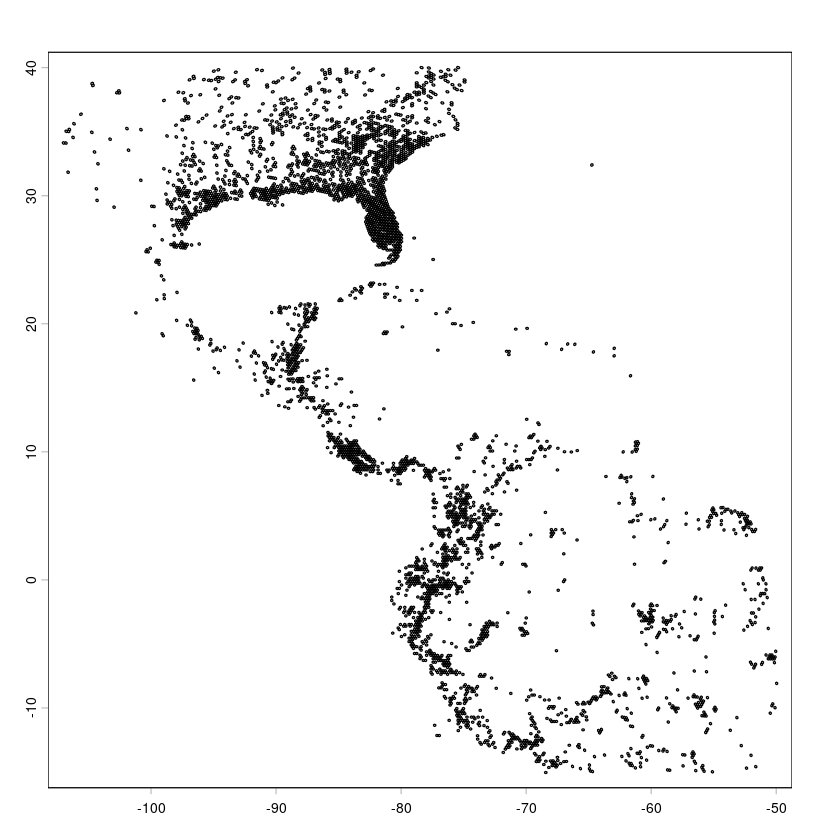

In [162]:
plot(hex_spatvector)

In [166]:
ebd_with_cells["species_observed"] = (ebd_with_cells["observation_count"] > 0)

ebd_agg <- ebd_with_cells %>% 
  group_by(cell) %>% 
  # summarize(obs_freq = mean(observation_count)) %>% 
  summarize(n_checklists = n(),
            n_detected = sum(species_observed),
            det_freq = mean(species_observed)) %>% 
  ungroup() %>%
  mutate(cell_ctr_lat = dgSEQNUM_to_GEO(dggs, cell)$lat_deg,
         cell_ctr_lon = dgSEQNUM_to_GEO(dggs, cell)$lon_deg)
# https://www.rdocumentation.org/packages/dggridR/versions/3.1.0/topics/dgSEQNUM_to_GEO

In [167]:
str(ebd_agg)

tibble [4,107 × 6] (S3: tbl_df/tbl/data.frame)
 $ cell        : num [1:4107] 135013 135499 138908 139151 139395 ...
 $ n_checklists: int [1:4107] 59 1 1 1 11 1 4 16 16 4 ...
 $ n_detected  : int [1:4107] 59 1 1 1 11 1 4 16 16 4 ...
 $ det_freq    : num [1:4107] 1 1 1 1 1 1 1 1 1 1 ...
 $ cell_ctr_lat: num [1:4107] 38.8 38.6 38.2 38 38 ...
 $ cell_ctr_lon: num [1:4107] -105 -105 -103 -103 -103 ...
